https://datahacker.rs/006-advanced-computer-vision-video-stabilization/

https://learnopencv.com/video-stabilization-using-point-feature-matching-in-opencv/

LUCAS-KANADE ADATTATO A ORB-RANSAC

# Stabilizzazione Video tramite ORB e RANSAC
Questo notebook implementa un approccio alternativo e più sofisticato alla stabilizzazione video. Anziché usare l'Optical Flow continuo (Lucas-Kanade), estrae **keypoints** tramite **ORB (Oriented FAST and Rotated BRIEF)** in ogni singolo frame e cerca tutti i vari match col frame precedente. Utilizza poi **RANSAC** per scartare i match errati (outlier) e stimare un movimento robusto.

I passaggi fondamentali sono:
1. **Estrazione e Matching (ORB + BFMatcher)**: Si rilevano i punti chiave e i loro descrittori per ogni frame. Si incrociano usando un algoritmo Brute-Force (`BFMatcher`) con filtro K-Nearest Neighbors (kNN) e il _Lowe's ratio test_.
2. **Filtraggio Outlier (RANSAC)**: Viene applicato RANSAC durante la stima della trasformazione geometrica. RANSAC discrimina inlier "veri" (coerenti col movimento della camera) da outlier anomali, garantendo che elementi in forte movimento nella scena non distorcano il tracciamento.
3. **Smoothing e Stabilizzazione**: Come nell'approccio Lucas-Kanade, la traiettoria accumulata viene smussata e il video viene trasformato (`warpAffine`) e leggermente scalato (`fixBorder`).

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

## Funzioni Ausiliarie
- `movingAverage` e `smooth`: Applicano un filtro a media mobile (Moving Average) per eliminare i picchi ad alta frequenza dalla traiettoria globale calcolata (il tremolio).
- `fixBorder`: Applica una zoom del +4% attorno al centro per evitare la visualizzazione di "bordi neri" quando l'immagine stabilizzata viene traslata o ruotata.

In [2]:
def movingAverage (curve, radius) :
    window_size = 2 * radius + 1 
    f = np.ones(window_size) / window_size # Filtro
    curve_pad = np.pad(curve, (radius, radius), 'edge') # Padding
    curve_smoothed = np.convolve(curve_pad, f, mode='same') # Convoluzione
    return curve_smoothed[radius:-radius] # Qui il padding viene rimosso

def smooth (trajectory) :
    smoothed_trajectory = np.copy(trajectory)
    for i in range (3) : # Filtra x, y e angolo
        smoothed_trajectory[:, i] = movingAverage(trajectory[:, i], radius=30)
    return smoothed_trajectory

def fixBorder (frame) :
    s = frame.shape
    # Zoomma 4%
    T = cv2.getRotationMatrix2D((s[1]/2, s[0]/2), 0, 1.04)
    return cv2.warpAffine(frame, T, (s[1], s[0]))

In [3]:
data_dir = "data"
folders = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')])
print(f"Cartelle trovate: {folders}")


Cartelle trovate: ['climbing1', 'climbing2', 'driving1', 'driving2', 'riding1', 'riding2', 'walking1', 'walking2']


## Inizializzazione ORB e Matcher
- `ORB_create(nfeatures=1000)`: Imposta l'estrazione di un massimo di 1000 keypoints per frame.
- `BFMatcher(NORM_HAMMING)`: Dato che i descrittori ORB sono binari, la metrica corretta per calcolare la distanza tra loro è la Distanza di Hamming.

In [4]:
# Inizializza ORB e Brute Force Matcher
orb = cv2.ORB_create(nfeatures=1000)
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)


## Elaborazione e Stabilizzazione
- Invece di "seguire" un punto fotogramma per fotogramma, qui in ogni frame si estraggono nuovi punti da zero, che vengono incrociati con quelli del frame precedente (`knnMatch(des1, des2, k=2)`).
- **Lowe's Ratio Test**: Scarta le corrispondenze incerte se i due match migliori sono troppo simili in termini di distanza (`m.distance < 0.75 * n.distance`), abbattendo drasticamente i falsi positivi.
- **RANSAC**: `cv2.estimateAffine2D` è chiamato col parametro `method=cv2.RANSAC`. Il codice visualizza graficamente gli "inlier" (i punti coerenti col movimento della camera, disegnati in verde) e gli "outlier" (disegnati in rosso per il debug).


Elaborazione: climbing1
Frame letti: 498


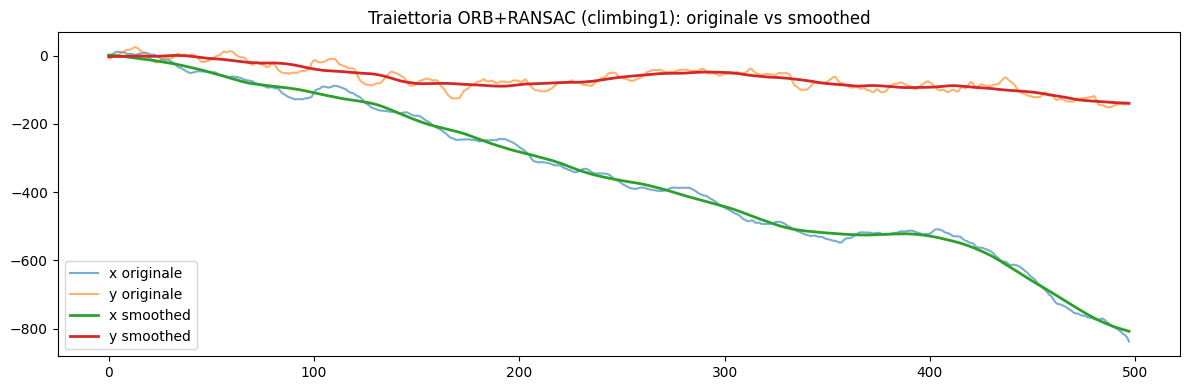

Video stabilizzati salvati in: data/climbing1/ORB+RANSAC

Elaborazione: climbing2
Frame letti: 498


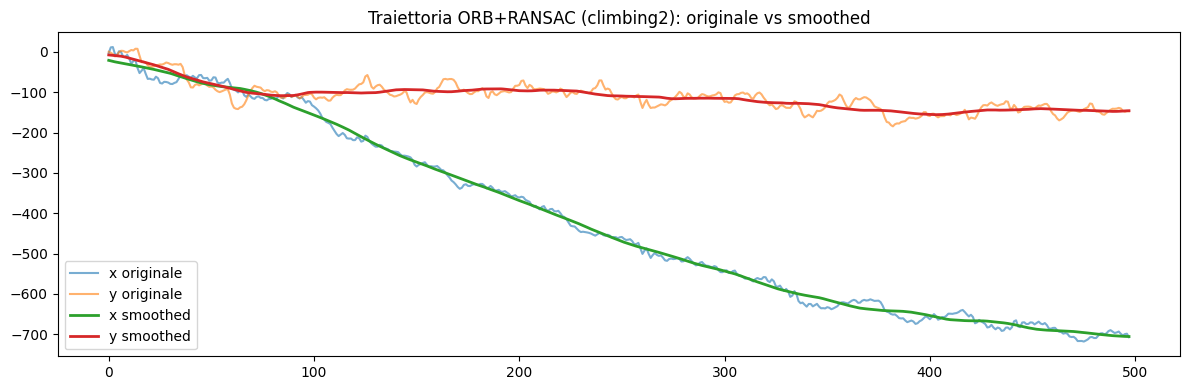

Video stabilizzati salvati in: data/climbing2/ORB+RANSAC

Elaborazione: driving1
Frame letti: 498


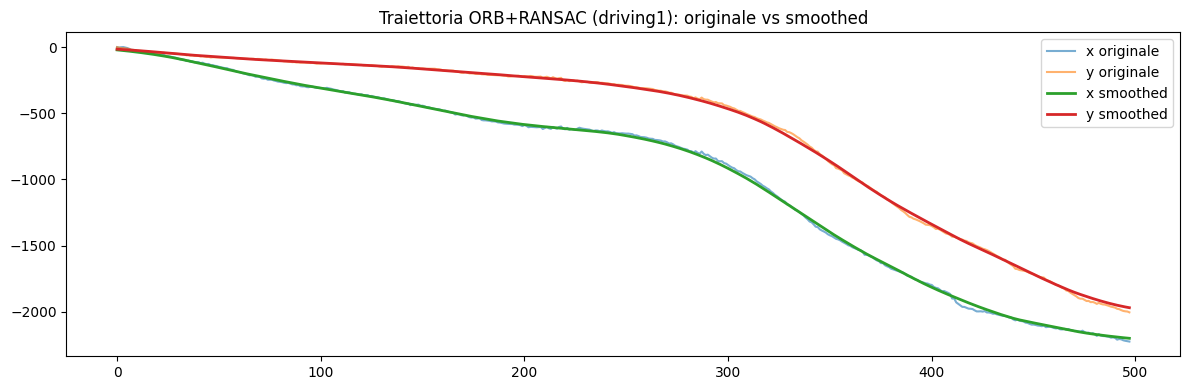

Video stabilizzati salvati in: data/driving1/ORB+RANSAC

Elaborazione: driving2
Frame letti: 498


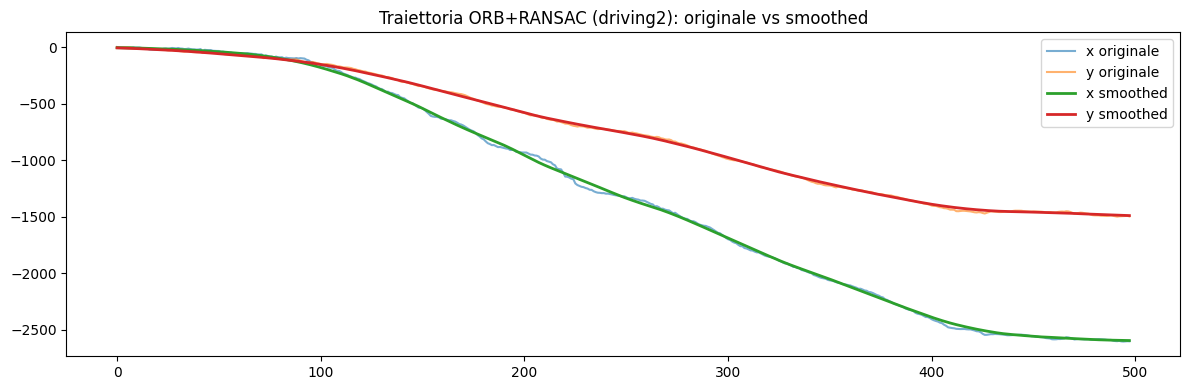

Video stabilizzati salvati in: data/driving2/ORB+RANSAC

Elaborazione: riding1
Frame letti: 498


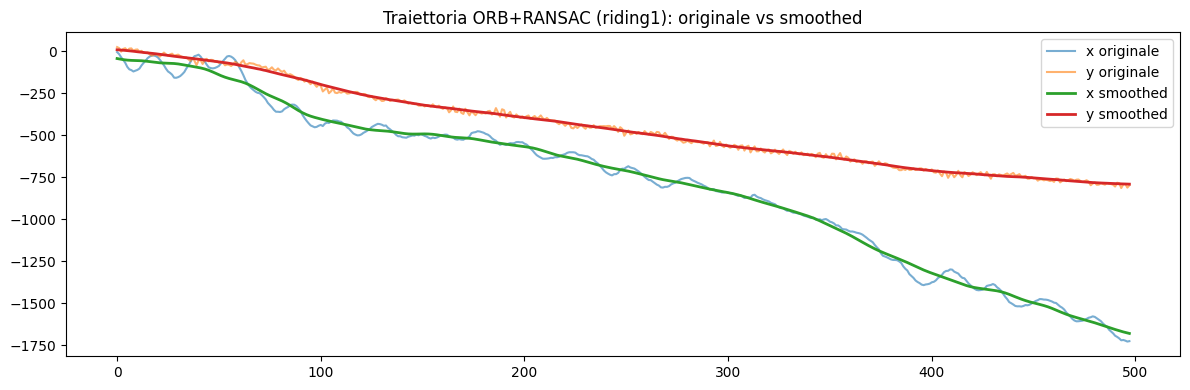

Video stabilizzati salvati in: data/riding1/ORB+RANSAC

Elaborazione: riding2
Frame letti: 498


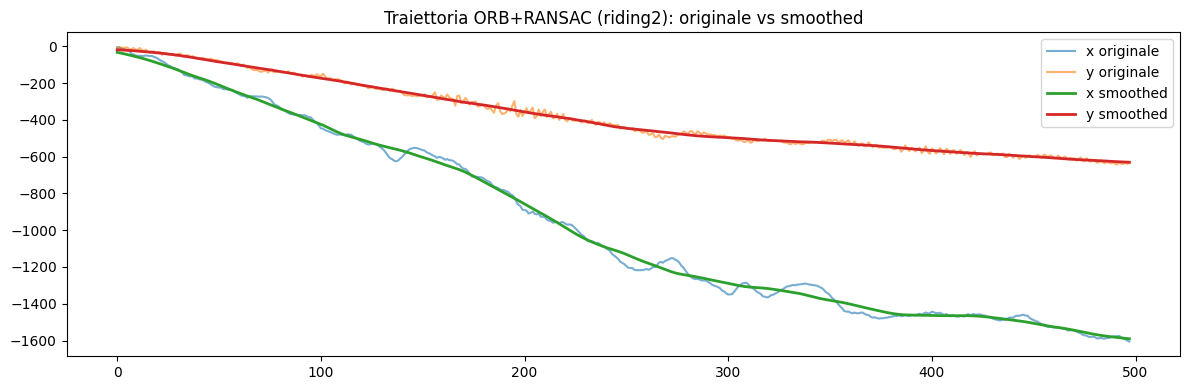

Video stabilizzati salvati in: data/riding2/ORB+RANSAC

Elaborazione: walking1
Frame letti: 698


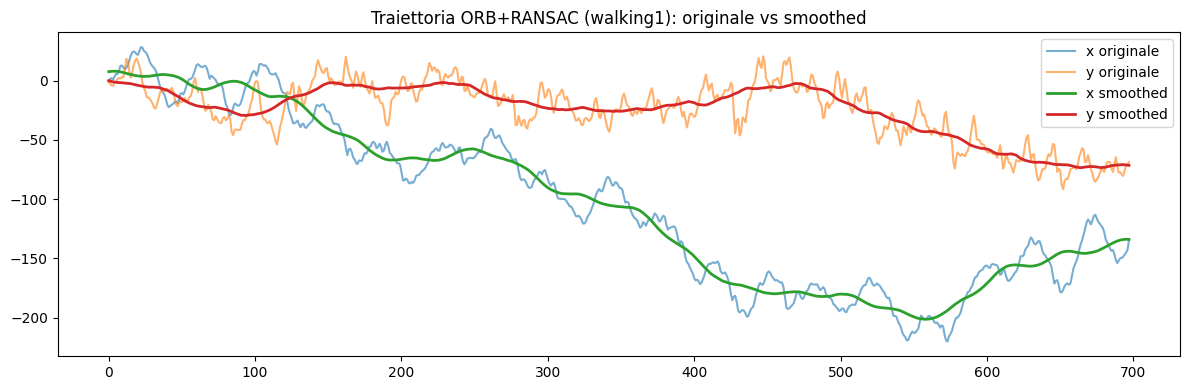

Video stabilizzati salvati in: data/walking1/ORB+RANSAC

Elaborazione: walking2
Frame letti: 248


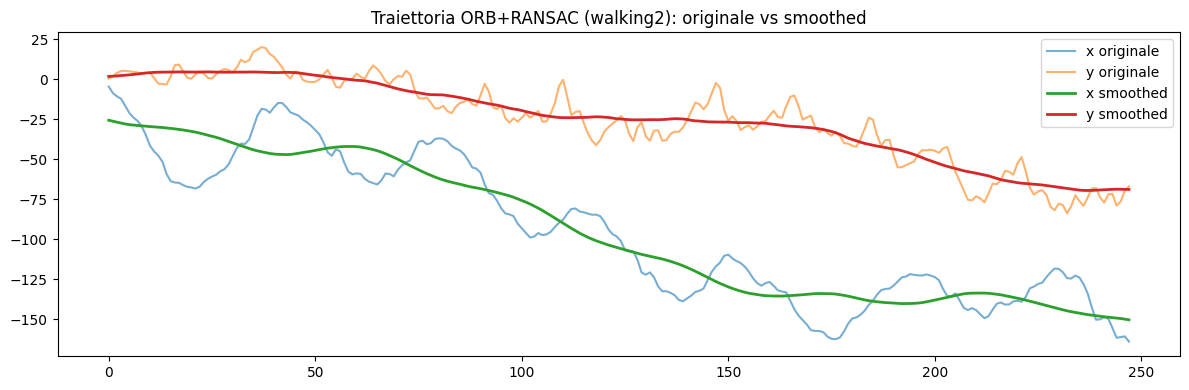

Video stabilizzati salvati in: data/walking2/ORB+RANSAC

Elaborazione completata!


In [5]:
for folder in folders:
    print(f"\n{'='*60}")
    print(f"Elaborazione: {folder}")
    print(f"{'='*60}")
    
    path = os.path.join(data_dir, folder)
    
    if not os.path.exists(os.path.join(path, "shaky.mp4")):
        print(f"SKIP: shaky.mp4 non trovato in {folder}")
        continue
    
    output_folder = os.path.join(path, "ORB+RANSAC")
    os.makedirs(output_folder, exist_ok=True)
    
    cap = cv2.VideoCapture(os.path.join(path, "shaky.mp4"))
    cap_groundtruth = cv2.VideoCapture(os.path.join(path, "groundtruth.mp4"))

    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_mask = cv2.VideoWriter(os.path.join(output_folder, "mask.mp4"), fourcc, fps, (w, h))

    success, prev = cap.read()
    if not success:
        print(f"ERRORE: Impossibile leggere il primo frame di {folder}")
        cap.release()
        continue

    prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

    transforms = np.zeros((n_frames - 1, 3), np.float32)
    frames_read = 0

    for frame_idx in range(n_frames - 1):
        success, curr = cap.read()
        if not success:
            break

        frames_read += 1
        curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)

        # Rilevamento keypoints e descrittori su entrambi i frame
        kp1, des1 = orb.detectAndCompute(prev_gray, None)
        kp2, des2 = orb.detectAndCompute(curr_gray, None)

        if des1 is None or des2 is None or len(kp1) < 4 or len(kp2) < 4:
            print(f"[{folder} - Frame {frame_idx}] Keypoint insufficienti, trasformazione nulla.")
            transforms[frame_idx] = [0, 0, 0]
            prev_gray = curr_gray.copy()
            continue

        # Matching kNN con Lowe's ratio test
        matches = bf.knnMatch(des1, des2, k=2)

        good = []
        for m, n in matches:
            if m.distance < 0.75 * n.distance:
                good.append(m)

        if len(good) < 10:
            print(f"[{folder} - Frame {frame_idx}] Match insufficienti ({len(good)}), trasformazione nulla.")
            transforms[frame_idx] = [0, 0, 0]
            prev_gray = curr_gray.copy()
            continue

        # Estrai coordinate punti corrispondenti
        pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
        pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

        # Stima trasformazione affine con RANSAC
        m_affine, inliers = cv2.estimateAffine2D(
            pts1, pts2,
            method=cv2.RANSAC,
            ransacReprojThreshold=3.0
        )

        if m_affine is None:
            print(f"[{folder} - Frame {frame_idx}] estimateAffine2D fallita, trasformazione nulla.")
            transforms[frame_idx] = [0, 0, 0]
            prev_gray = curr_gray.copy()
            continue

        dx = m_affine[0, 2]
        dy = m_affine[1, 2]
        da = np.arctan2(m_affine[1, 0], m_affine[0, 0])
        transforms[frame_idx] = [dx, dy, da]

        # Disegna solo gli inlier trovati da RANSAC
        mask_draw = np.zeros_like(curr)
        if inliers is not None:
            inlier_idx = np.where(inliers.ravel() == 1)[0]
            for idx in inlier_idx:
                pt1 = tuple(map(int, pts1[idx]))
                pt2 = tuple(map(int, pts2[idx]))
                mask_draw = cv2.line(mask_draw, pt1, pt2, (0, 255, 0), 1)
                curr = cv2.circle(curr, pt2, 5, (0, 255, 0), -1)

        # Disegna gli outlier in rosso per confronto visivo
        if inliers is not None:
            outlier_idx = np.where(inliers.ravel() == 0)[0]
            for idx in outlier_idx:
                pt2 = tuple(map(int, pts2[idx]))
                curr = cv2.circle(curr, pt2, 5, (0, 0, 255), -1)

        img = cv2.add(curr, mask_draw)

        # Testo informativo sul frame
        n_inliers  = int(inliers.sum()) if inliers is not None else 0
        n_outliers = len(good) - n_inliers
        cv2.putText(img, f"Inliers: {n_inliers}  Outliers: {n_outliers}",
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

        out_mask.write(img)

        prev_gray = curr_gray.copy()

    cap.release()
    out_mask.release()

    # Tronca ai frame effettivamente letti
    transforms = transforms[:frames_read]

    print(f"Frame letti: {frames_read}")

    trajectory = np.cumsum(transforms, axis=0)
    smoothed_trajectory = smooth(trajectory)
    difference = smoothed_trajectory - trajectory
    transforms_smooth = transforms + difference

    # Plot traiettoria originale vs smoothed
    time = np.arange(len(trajectory))
    plt.figure(figsize=(12, 4))
    plt.plot(time, trajectory[:, 0], label='x originale', alpha=0.6)
    plt.plot(time, trajectory[:, 1], label='y originale', alpha=0.6)
    plt.plot(time, smoothed_trajectory[:, 0], label='x smoothed', linewidth=2)
    plt.plot(time, smoothed_trajectory[:, 1], label='y smoothed', linewidth=2)
    plt.legend()
    plt.title(f"Traiettoria ORB+RANSAC ({folder}): originale vs smoothed")
    plt.tight_layout()
    plt.show()

    cap = cv2.VideoCapture(os.path.join(path, "shaky.mp4"))
    cap_groundtruth = cv2.VideoCapture(os.path.join(path, "groundtruth.mp4"))

    out_shaky = cv2.VideoWriter(os.path.join(output_folder, "comparison_shaky.mp4"), fourcc, fps, (2 * w, h))
    out_groundtruth = cv2.VideoWriter(os.path.join(output_folder, "comparison_groundtruth.mp4"), fourcc, fps, (2 * w, h))

    for i in range(frames_read):
        success, frame = cap.read()
        if not success:
            break

        success, frame_gt = cap_groundtruth.read()
        if not success:
            break

        dx = transforms_smooth[i, 0]
        dy = transforms_smooth[i, 1]
        da = transforms_smooth[i, 2]

        # Ricostruisce matrice di trasformazione affine
        m = np.array([
            [np.cos(da), -np.sin(da), dx],
            [np.sin(da),  np.cos(da), dy]
        ], dtype=np.float32)

        frame_stabilized = cv2.warpAffine(frame, m, (w, h))
        frame_stabilized = fixBorder(frame_stabilized)

        frame_shaky_out = cv2.hconcat([frame, frame_stabilized])
        frame_gt_out    = cv2.hconcat([frame_gt, frame_stabilized])

        out_shaky.write(frame_shaky_out)
        out_groundtruth.write(frame_gt_out)

        cv2.waitKey(10)

    cap.release()
    cap_groundtruth.release()
    out_shaky.release()
    out_groundtruth.release()

    print(f"Video stabilizzati salvati in: {output_folder}")

cv2.destroyAllWindows()
print(f"\n{'='*60}")
print("Elaborazione completata!")
print(f"{'='*60}")


## Confronto: Lucas-Kanade vs ORB+RANSAC
In questa cella finale i video stabilizzati ottenuti con Lucas-Kanade vengono concatenati orizzontalmente con quelli appena calcolati tramite ORB+RANSAC.
Ci permette così di fare una valutazione qualitativa dei due modelli per poter confrontare visivamente l'applicazione degli algoritmi.

In [6]:
print(f"\n{'='*60}")
print("Creazione video di confronto LK vs ORB+RANSAC")
print(f"{'='*60}")

for folder in folders:
    print(f"\nConfronto per: {folder}")
    
    path = os.path.join(data_dir, folder)
    lk_folder = os.path.join(path, "Lucas-Kanade Optical Flow")
    orb_folder = os.path.join(path, "ORB+RANSAC")
    
    if not os.path.exists(lk_folder) or not os.path.exists(orb_folder):
        print(f"SKIP: Cartelle di output non trovate per {folder}")
        continue
    
    lk_video = os.path.join(lk_folder, "comparison_shaky.mp4")
    orb_video = os.path.join(orb_folder, "comparison_shaky.mp4")
    
    if not os.path.exists(lk_video) or not os.path.exists(orb_video):
        print(f"SKIP: Video di confronto non trovati per {folder}")
        continue
    
    cap_lk = cv2.VideoCapture(lk_video)
    cap_orb = cv2.VideoCapture(orb_video)
    
    fps = cap_lk.get(cv2.CAP_PROP_FPS)
    
    # I video sono già (2*w, h), quindi la metà destra è il frame stabilizzato
    full_w = int(cap_lk.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap_lk.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w = full_w // 2  # larghezza del singolo frame stabilizzato
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    comparison_output = os.path.join(path, "LucasKanade_vs_ORB+RANSAC.mp4")
    out = cv2.VideoWriter(comparison_output, fourcc, fps, (2 * w, h))
    
    frame_count = 0
    while True:
        success_lk, frame_lk = cap_lk.read()
        success_orb, frame_orb = cap_orb.read()
        
        if not success_lk or not success_orb:
            break
        
        frame_count += 1
        
        # Estrai solo la metà destra (frame stabilizzato) da ciascun video
        stabilized_lk = frame_lk[:, w:, :]
        stabilized_orb = frame_orb[:, w:, :]
        
        # Aggiungi etichetta testo su ciascun frame
        cv2.putText(stabilized_lk, "Lucas-Kanade",
                    (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
        cv2.putText(stabilized_orb, "ORB+RANSAC",
                    (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 2)
        
        # Affianca i due frame stabilizzati
        comparison = cv2.hconcat([stabilized_lk, stabilized_orb])
        out.write(comparison)
    
    cap_lk.release()
    cap_orb.release()
    out.release()
    
    print(f"Video di confronto salvato: {comparison_output} ({frame_count} frame)")

cv2.destroyAllWindows()
print(f"\n{'='*60}")
print("Confronto completato!")
print(f"{'='*60}")



Creazione video di confronto LK vs ORB+RANSAC

Confronto per: climbing1
Video di confronto salvato: data/climbing1/LucasKanade_vs_ORB+RANSAC.mp4 (498 frame)

Confronto per: climbing2
Video di confronto salvato: data/climbing2/LucasKanade_vs_ORB+RANSAC.mp4 (498 frame)

Confronto per: driving1
Video di confronto salvato: data/driving1/LucasKanade_vs_ORB+RANSAC.mp4 (498 frame)

Confronto per: driving2
Video di confronto salvato: data/driving2/LucasKanade_vs_ORB+RANSAC.mp4 (498 frame)

Confronto per: riding1
Video di confronto salvato: data/riding1/LucasKanade_vs_ORB+RANSAC.mp4 (498 frame)

Confronto per: riding2
Video di confronto salvato: data/riding2/LucasKanade_vs_ORB+RANSAC.mp4 (498 frame)

Confronto per: walking1
Video di confronto salvato: data/walking1/LucasKanade_vs_ORB+RANSAC.mp4 (698 frame)

Confronto per: walking2
Video di confronto salvato: data/walking2/LucasKanade_vs_ORB+RANSAC.mp4 (248 frame)

Confronto completato!
